# Tahap 1 – Memount Google Drive Dataset Face Only Haar dan Data Pre Processing

In [3]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/Dataset_Face_Only"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [5]:
import os

datagen = ImageDataGenerator(
rescale=1./255,
validation_split=0.2

)

In [6]:
if not os.path.exists(dataset_path):
    print(f"Error Path Dataset.")
else:
    train_data = datagen.flow_from_directory(
        dataset_path,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        subset='training'
    )
    val_data = datagen.flow_from_directory(
        dataset_path,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
    )

Found 416 images belonging to 7 classes.
Found 99 images belonging to 7 classes.


# Tahap 2 – Membuat Model Baseline dengan CNN

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.1815 - loss: 4.2723 - val_accuracy: 0.2828 - val_loss: 1.8783
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.2841 - loss: 1.8171 - val_accuracy: 0.3737 - val_loss: 1.6551
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.5737 - loss: 1.2964 - val_accuracy: 0.4646 - val_loss: 1.4769
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7682 - loss: 0.7692 - val_accuracy: 0.5051 - val_loss: 1.4734
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8861 - loss: 0.3952 - val_accuracy: 0.5859 - val_loss: 1.2290
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9626 - loss: 0.1852 - val_accuracy: 0.5354 - val_loss: 1.3998
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9769 - loss: 0.1278 - val_accuracy: 0.4848 - val_loss: 1.8405
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9948 - loss: 0.0525 - val_accuracy: 0.5758 - val_loss:

# Tahap 3 – Implementasi Transfer Learning

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)
transfer_model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.1419 - loss: 2.2951 - val_accuracy: 0.3030 - val_loss: 1.7669
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.3867 - loss: 1.6002 - val_accuracy: 0.4545 - val_loss: 1.4954
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5650 - loss: 1.2647 - val_accuracy: 0.5556 - val_loss: 1.2878
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6950 - loss: 1.0262 - val_accuracy: 0.6263 - val_loss: 1.1822
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7869 - loss: 0.8594 - val_accuracy: 0.6061 - val_loss: 1.0902
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7960 - loss: 0.7882 - val_accuracy: 0.6970 - val_loss: 1.0235
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8410 - loss: 0.6700 - val_accuracy: 0.6869 - val_loss: 0.9691
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8820 - loss: 0.5891 - val_accuracy: 0.7071 - val_loss:

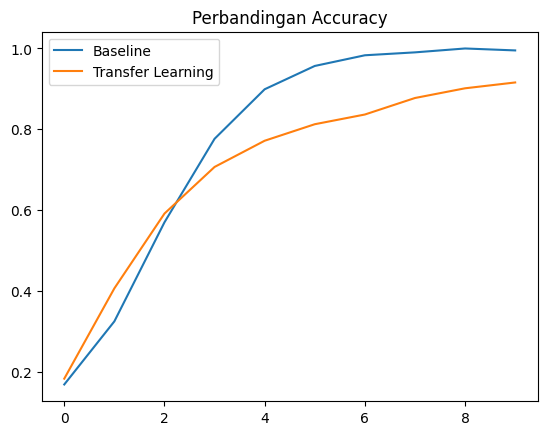

In [12]:
plt.plot(history_baseline.history['accuracy'])
plt.plot(history_transfer.history['accuracy'])
plt.legend(['Baseline', 'Transfer Learning'])
plt.title("Perbandingan Accuracy")

plt.show()